<a href="https://colab.research.google.com/github/tommypolpo/geron-hands_on_ML/blob/main/c4_lin_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(15.0))

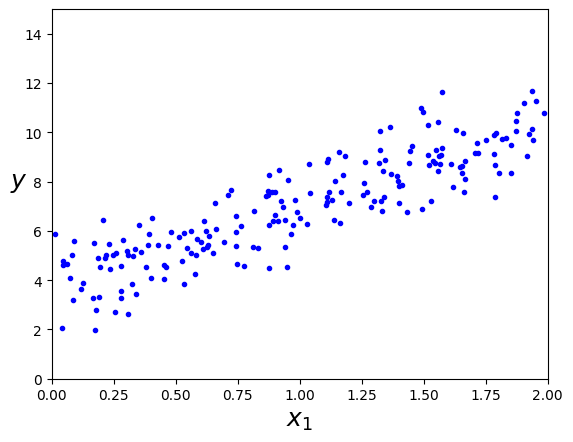

In [ ]:
#Let's generate some linear-looking data to understand what's going on
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42) #random number generator
m = 200 #number of instances in the training set

# column vector, each row determines one x in the training set X:
# x_0=1 by default, x_1 is a random number between 0 and 2 (x_0 not in this matrix X)
X = 2*rng.random((m,1))

#to generate the predicted value we add some Gaussian noise
y = 4+3*X+rng.standard_normal((m,1))

plt.plot(X,y,'b.')
plt.xlabel('$x_1$',fontsize=18)
plt.ylabel('$y$',rotation=0,fontsize=18)
plt.axis([0,2,0,15])

In [ ]:
# Now that we have the data, let's find the parameters theta_0 and theta_1
# that minimize the mean square error
from sklearn.preprocessing import add_dummy_feature

X_b=add_dummy_feature(X) #we add the first column of X of all x_0=1
#now X_b is the true training set as by the theory

theta_best=np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best


array([[3.69084138],
       [3.32960458]])

In [ ]:
# we can make predictions using theta_best
X_new=np.array([[0], [2]]) #two new data points at the beginning and end of the range
X_new_b=add_dummy_feature(X_new) #add x0=1 to each instance
y_predict=X_new_b @ theta_best #this is a vector
y_predict

array([[ 3.69084138],
       [10.35005055]])

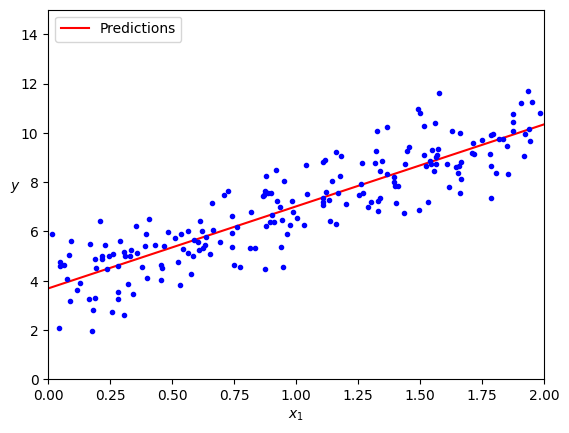

In [ ]:
# We the predicttions for this 2 new data points we can plot the predictions
plt.plot(X_new,y_predict,'r-', label="Predictions")
plt.plot(X,y,"b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([0,2,0,15])
plt.show()


In [ ]:
# Using Scikit-Learn is straightforward:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_
#notice that the coefficients are separated

(array([3.69084138]), array([[3.32960458]]))

In [ ]:
lin_reg.predict(X_new)
#same values as y_predict coputed above

array([[ 3.69084138],
       [10.35005055]])

In [ ]:
#let's implement batch gradient descent
eta=0.1 # learning rate
n_epochs = 1000
m = len(X_b) #number of instances

rng=np.random.default_rng(seed=42) #random number generator
theta=rng.random((2,1)) #random initialization of the gradient descent

for epoch in range(n_epochs):
    gradients=2/m*X_b.T @(X_b @ theta -y)
    theta = theta - eta*gradients

theta
---#same result as the normal equation

array([[3.69084138],
       [3.32960458]])